[INFO] DEVICE = cuda
[19:16:18] Build sample lists.
[TIME] Build sample lists: 9.32s, 18565.96 samples/s, 0.05 ms/sample
[INFO] train samples = 121064
[INFO] val samples   = 25943
[INFO] test samples  = 25943
[OK] All checked images match (64, 64).
[OK] All checked images match (64, 64).
[OK] All checked images match (64, 64).

Sanity check: Official CNN VGG11-BN-64
Input shape  = (2, 3, 64, 64)
Output shape = (2, 2)

Stage1: None vs Defect
[19:16:30] Loaded weights: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\official_cnn_vgg11bn_16\stage1_official_vgg11bn_64.pt
[TIME] Stage1 train/load total: 1.31s, 111941.86 samples/s, 0.01 ms/sample

Stage2 class weights
Center       class=0  weight=2.0552
Donut        class=1  weight=15.8812
Edge-loc     class=2  weight=1.7009
Edge-ring    class=3  weight=0.9117
Loc          class=4  weight=2.4564
Random       class=5  weight=10.1944
Scratch      class=6  weight=7.3985
Near-Full    class=7  weight=59.4017
SUM = 100.0000
[TIME] Compute Stage

[TIME] Stage1 test inference: 48.12s, 539.13 samples/s, 1.85 ms/sample


[TIME] Stage2 test inference: 46.99s, 552.09 samples/s, 1.81 ms/sample
[TIME] Total two-stage test inference: 95.11s, 272.77 samples/s, 3.67 ms/sample
[INFO] Saved CSV: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\official_cnn_vgg11bn_16\test_two_stage_official_vgg11bn_64.csv

TEST Evaluation

=== TEST Stage1 Report ===
              precision    recall  f1-score   support

        None       0.99      0.97      0.98     22115
      Defect       0.86      0.96      0.91      3828

    accuracy                           0.97     25943
   macro avg       0.93      0.97      0.95     25943
weighted avg       0.97      0.97      0.97     25943

[INFO] Saved confusion matrix: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\official_cnn_vgg11bn_16\cm_stage1_official_vgg11bn_64.png


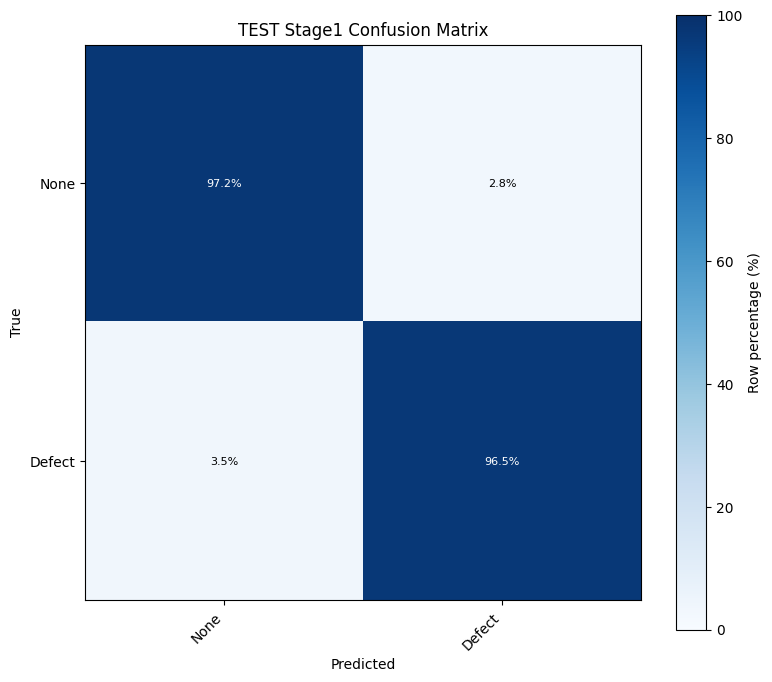


=== TEST Stage2 Report (defect-only, after Stage1 pass) ===
              precision    recall  f1-score   support

      Center       0.96      0.98      0.97       626
       Donut       0.80      0.89      0.84        83
    Edge-loc       0.90      0.90      0.90       749
   Edge-ring       0.98      0.98      0.98      1443
         Loc       0.84      0.80      0.82       496
      Random       0.86      0.92      0.89       130
     Scratch       0.78      0.78      0.78       145
   Near-Full       0.96      1.00      0.98        22

    accuracy                           0.93      3694
   macro avg       0.88      0.91      0.89      3694
weighted avg       0.93      0.93      0.93      3694

[INFO] Saved confusion matrix: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\official_cnn_vgg11bn_16\cm_stage2_official_vgg11bn_64.png


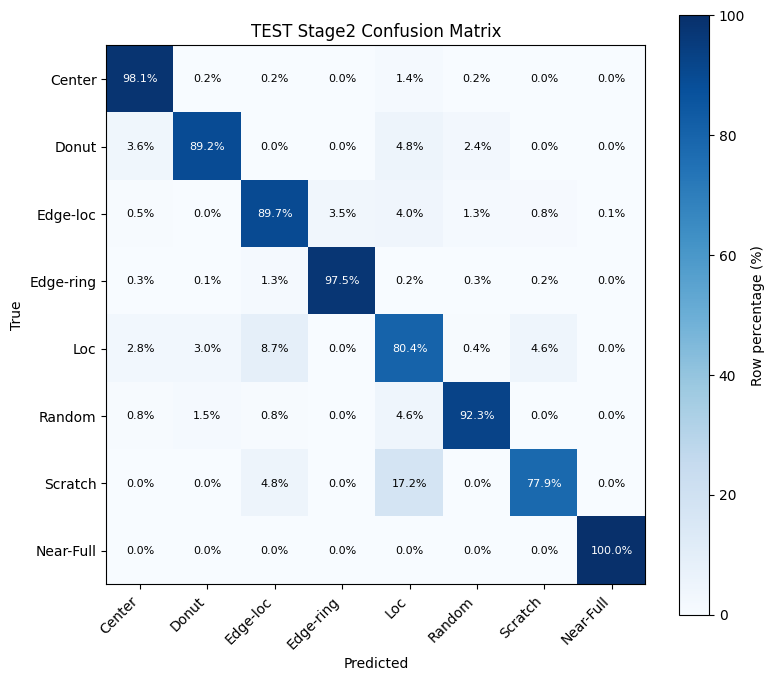


=== TEST Two-Stage Final Report (K+1) ===
              precision    recall  f1-score   support

        None       0.99      0.97      0.98     22115
      Center       0.83      0.95      0.89       644
       Donut       0.78      0.89      0.83        83
    Edge-loc       0.69      0.86      0.76       779
   Edge-ring       0.96      0.97      0.97      1452
         Loc       0.64      0.74      0.69       539
      Random       0.76      0.92      0.83       130
     Scratch       0.49      0.63      0.55       179
   Near-Full       0.92      1.00      0.96        22

    accuracy                           0.96     25943
   macro avg       0.79      0.88      0.83     25943
weighted avg       0.97      0.96      0.96     25943

Final macro-F1 = 0.83
[INFO] Saved confusion matrix: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\official_cnn_vgg11bn_16\cm_final_official_vgg11bn_64.png


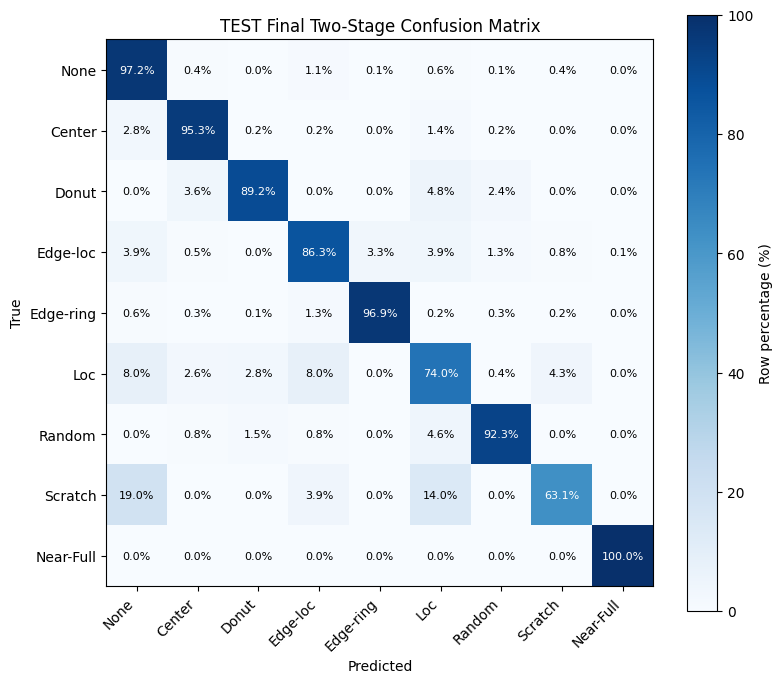

[TIME] Test inference + evaluation total: 98.57s, 263.19 samples/s, 3.80 ms/sample
[TIME] Full program total: 1301.20s, 132.92 samples/s, 7.52 ms/sample
[INFO] Saved CSV: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\official_cnn_vgg11bn_16\time_efficiency_analysis_official_vgg11bn_64.csv

Time / Efficiency Analysis
                            stage  elapsed_sec  num_samples  batch_size  samples_per_sec  ms_per_sample  total_params  trainable_params                                                             note
               Build sample lists         9.32     172950.0         NaN         18565.96           0.05           NaN               NaN                                 Read file paths and class labels
          Stage1 train/load total         1.31     147007.0        16.0        111941.86           0.01    22137345.0        22137345.0       Includes loading existing weights or training from scratch
     Compute Stage2 class weights         0.01     121064.0         NaN   

In [1]:
# =========================================================
# Official CNN VGG11-BN-64 Two-Stage Wafer Classification - PyTorch
# ---------------------------------------------------------
# Model : torchvision official VGG11-BN adjusted for 64x64 wafer map
# Stage1: Binary classification (None vs Defect)
# Stage2: Multiclass defect-only classification (8 defect classes)
#
# Optional:
#   - Greedy search for best Stage2 defect-only augmentation pipeline
#   - Apply selected pipeline only to Stage2 training
#
# Outputs:
#   - Stage1 / Stage2 / Final classification reports
#   - Confusion matrix PNG files
#   - Test prediction CSV
#   - Greedy augmentation CSV
#   - Stage1 / Stage2 .pt weights
# =========================================================




# =========================================================
# 0. Package Installation Notes
# =========================================================
# pip install numpy pandas matplotlib opencv-python pillow scikit-learn tqdm torch torchvision




# =========================================================
# 1. Imports
# =========================================================
import os
import time
import copy
import random
import zlib
from datetime import datetime
from typing import List, Optional


import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance, ImageOps


import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm




# =========================================================
# 2. Global Config
# =========================================================
SEED = 42


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = torch.cuda.is_available()
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] DEVICE = {DEVICE}")




# ===== Dataset path =====
# 資料夾需要長這樣：
# DATASET_DIR/
#   train/Center, train/Donut, ..., train/None
#   val/Center,   val/Donut,   ..., val/None
#   test/Center,  test/Donut,  ..., test/None
DATASET_DIR = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\newdataset"


TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")




# ===== Output path =====
VGG_OUT_DIR = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\official_cnn_vgg11bn_16"
os.makedirs(VGG_OUT_DIR, exist_ok=True)




# ===== Class setting =====
NONE_CLASS_NAME = "None"


CLASS_LIST = [
    "Center", "Donut", "Edge-loc", "Edge-ring", "Loc",
    "Random", "Scratch", "Near-Full", "None"
]
DEFECT_CLASS_LIST = [c for c in CLASS_LIST if c != NONE_CLASS_NAME]




# ===== Image setting =====
# 本研究的 wafer map 圖片已在前處理階段統一為 64x64。
IMAGE_SIZE = (64, 64)
CHECK_IMAGE_SIZE = True




# ===== Model setting =====
# True 會使用 ImageNet pretrained VGG11-BN。
# 若你的報告希望寫「從零訓練」，請保持 False。
USE_IMAGENET_PRETRAINED_VGG = False


# 若 USE_IMAGENET_PRETRAINED_VGG=True，建議改用 ImageNet normalization。
USE_IMAGENET_NORMALIZE = False


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


VGG_DROPOUT = 0.5




# ===== Training setting =====
BATCH_SIZE = 16
NUM_WORKERS = 0


EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 15


LR = 1e-4
WEIGHT_DECAY = 1e-4


THRESH_STAGE1 = 0.5


FORCE_RETRAIN_STAGE1 = False
FORCE_RETRAIN_STAGE2 = False




# ===== Early stopping =====
PATIENCE_STAGE1 = 5
PATIENCE_STAGE2 = 7




# ===== Greedy augmentation search =====
RUN_GREEDY = True
USE_GREEDY_FOR_STAGE2 = True


TRIAL_EPOCHS = 3
MAX_ROUNDS = 3
MIN_GAIN = 0.003
SEARCH_REPEATS = 5
FINAL_REPEATS = 15


# 限制 greedy trial 的 batch 數，避免 trial 太久。
# None 代表使用全部資料。
GREEDY_TRAIN_MAX_BATCHES = 100
GREEDY_VAL_MAX_BATCHES = 50


APPLY_AUG_PROB = 0.7


# 建議先只保留較合理且不會過度破壞 wafer map 語意的增強。
CANDIDATES = ["dilation", "affine", "noise", "erase", "sharpen"]




# ===== Output files =====
STAGE1_WEIGHT_PATH = os.path.join(VGG_OUT_DIR, "stage1_official_vgg11bn_64.pt")
STAGE2_WEIGHT_PATH = os.path.join(VGG_OUT_DIR, "stage2_official_vgg11bn_64.pt")


OUT_TEST_CSV = os.path.join(VGG_OUT_DIR, "test_two_stage_official_vgg11bn_64.csv")
OUT_GREEDY_CSV = os.path.join(VGG_OUT_DIR, "greedy_stage2_aug_official_vgg11bn_64.csv")


OUT_CM_STAGE1 = os.path.join(VGG_OUT_DIR, "cm_stage1_official_vgg11bn_64.png")
OUT_CM_STAGE2 = os.path.join(VGG_OUT_DIR, "cm_stage2_official_vgg11bn_64.png")
OUT_CM_FINAL = os.path.join(VGG_OUT_DIR, "cm_final_official_vgg11bn_64.png")

# ===== Time / efficiency analysis output =====
OUT_TIME_ANALYSIS_CSV = os.path.join(VGG_OUT_DIR, "time_efficiency_analysis_official_vgg11bn_64.csv")
TIME_ANALYSIS_ROWS = []




# =========================================================
# 3. Utility
# =========================================================
def log(msg: str):
    now = datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] {msg}", flush=True)




def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)




def make_unlocked_output_path(path: str) -> str:
    """If CSV is locked by Excel, save as a timestamped alternative file."""
    root, ext = os.path.splitext(path)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    return f"{root}_{ts}{ext}"




def save_csv(df: pd.DataFrame, path: str):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        df.to_csv(path, index=False, encoding="utf-8-sig")
        print(f"[INFO] Saved CSV: {path}")
    except PermissionError:
        alt_path = make_unlocked_output_path(path)
        df.to_csv(alt_path, index=False, encoding="utf-8-sig")
        print(f"[WARN] Permission denied: {path}")
        print(f"[INFO] Saved CSV instead: {alt_path}")




def plot_cm(cm, labels, title, normalize="true", show_counts=False, save_path=None):
    import matplotlib.pyplot as plt


    cm = np.asarray(cm, dtype=np.int64)
    labels = list(labels)


    if normalize == "true":
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_show = np.divide(
            cm.astype(np.float64),
            row_sum,
            out=np.zeros_like(cm, dtype=np.float64),
            where=row_sum != 0,
        ) * 100.0
        vmin, vmax = 0, 100
        colorbar_label = "Row percentage (%)"
    else:
        cm_show = cm.astype(np.float64)
        vmin, vmax = None, None
        colorbar_label = "Count"


    fig_w = max(8, len(labels) * 0.9)
    fig_h = max(7, len(labels) * 0.75)


    plt.figure(figsize=(fig_w, fig_h))
    plt.imshow(cm_show, interpolation="nearest", cmap="Blues", vmin=vmin, vmax=vmax)
    plt.title(title)
    cbar = plt.colorbar()
    cbar.set_label(colorbar_label)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")


    for i in range(cm.shape[0]):
        row_total = cm[i].sum()
        for j in range(cm.shape[1]):
            count = int(cm[i, j])
            pct = (count / row_total * 100.0) if row_total > 0 else 0.0
            if normalize == "true":
                # 混淆矩陣內只顯示百分比，不顯示數量。
                text = f"{pct:.1f}%"
                color = "white" if cm_show[i, j] > 50 else "black"
            else:
                # 若未來改成 normalize=False，仍只顯示數量。
                text = str(count)
                color = "white" if cm_show[i, j] > cm_show.max() * 0.5 else "black"
            plt.text(j, i, text, ha="center", va="center", color=color, fontsize=8)


    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"[INFO] Saved confusion matrix: {save_path}")
    plt.show()




def safe_load_weights(model: nn.Module, weight_path: str) -> bool:
    if not os.path.exists(weight_path):
        return False
    try:
        try:
            state = torch.load(weight_path, map_location=DEVICE, weights_only=True)
        except TypeError:
            state = torch.load(weight_path, map_location=DEVICE)
        model.load_state_dict(state)
        log(f"Loaded weights: {weight_path}")
        return True
    except Exception as e:
        log(f"Failed to load weights: {weight_path}")
        log(f"Reason: {repr(e)}")
        return False




def save_weights(model: nn.Module, weight_path: str):
    os.makedirs(os.path.dirname(weight_path), exist_ok=True)
    torch.save(model.state_dict(), weight_path)
    log(f"Saved weights: {weight_path}")




def sync_cuda():
    """Synchronize CUDA to make GPU timing more accurate."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()




def start_timer():
    sync_cuda()
    return time.perf_counter()




def stop_timer(t0):
    sync_cuda()
    return time.perf_counter() - t0




def count_parameters(model: nn.Module):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return int(total_params), int(trainable_params)




def add_time_record(
    stage: str,
    elapsed_sec: float,
    num_samples: Optional[int] = None,
    batch_size: Optional[int] = None,
    total_params: Optional[int] = None,
    trainable_params: Optional[int] = None,
    note: str = "",
):
    samples_per_sec = np.nan
    ms_per_sample = np.nan

    if num_samples is not None and num_samples > 0 and elapsed_sec > 0:
        samples_per_sec = num_samples / elapsed_sec
        ms_per_sample = elapsed_sec * 1000.0 / num_samples

    row = {
        "stage": stage,
        "elapsed_sec": round(float(elapsed_sec), 2),
        "num_samples": np.nan if num_samples is None else int(num_samples),
        "batch_size": np.nan if batch_size is None else int(batch_size),
        "samples_per_sec": np.nan if pd.isna(samples_per_sec) else round(float(samples_per_sec), 2),
        "ms_per_sample": np.nan if pd.isna(ms_per_sample) else round(float(ms_per_sample), 2),
        "total_params": np.nan if total_params is None else int(total_params),
        "trainable_params": np.nan if trainable_params is None else int(trainable_params),
        "note": note,
    }
    TIME_ANALYSIS_ROWS.append(row)

    msg = f"[TIME] {stage}: {row['elapsed_sec']:.2f}s"
    if not pd.isna(row["samples_per_sec"]):
        msg += f", {row['samples_per_sec']:.2f} samples/s"
    if not pd.isna(row["ms_per_sample"]):
        msg += f", {row['ms_per_sample']:.2f} ms/sample"
    print(msg)




def save_time_analysis():
    if len(TIME_ANALYSIS_ROWS) == 0:
        print("[WARN] No time analysis records to save.")
        return

    df_time = pd.DataFrame(TIME_ANALYSIS_ROWS)
    save_csv(df_time, OUT_TIME_ANALYSIS_CSV)

    print("\n==============================")
    print("Time / Efficiency Analysis")
    print("==============================")
    print(df_time.to_string(index=False))




# =========================================================
# 4. Data Building
# =========================================================
def build_samples(root_dir: str, classes: List[str]):
    samples = []
    class_to_idx = {c: i for i, c in enumerate(classes)}


    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            print(f"[WARN] Class folder not found: {cls_dir}")
            continue


        for fn in sorted(os.listdir(cls_dir)):
            fp = os.path.join(cls_dir, fn)
            if not os.path.isfile(fp):
                continue
            if not fn.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp")):
                continue


            samples.append({
                "path": os.path.normpath(fp),
                "relpath": os.path.join(cls, fn),
                "class_name": cls,
                "class_idx": class_to_idx[cls],
            })


    return samples, class_to_idx




def ensure_nonempty_samples(samples, name):
    if len(samples) == 0:
        raise RuntimeError(f"{name} has no samples. Please check dataset path and class folders.")




def check_image_size(samples, expected_size=(64, 64), max_print=10):
    if not CHECK_IMAGE_SIZE:
        return


    bad = []
    for s in samples:
        with Image.open(s["path"]) as img:
            if img.size != expected_size:
                bad.append((s["path"], img.size))
                if len(bad) >= max_print:
                    break


    if len(bad) == 0:
        print(f"[OK] All checked images match {expected_size}.")
    else:
        print(f"[WARN] Found images not equal to {expected_size}:")
        for path, size in bad:
            print(" ", path, size)




# =========================================================
# 5. Wafer-Specific Augmentation
# =========================================================
def wafer_dilation(img):
    """Wafer-map dilation augmentation.

    使用 2x2 kernel 對影像做膨脹處理，讓 wafer defect pattern 的亮區或線條變粗。
    """
    img_np = np.array(img)
    kernel = np.ones((2, 2), np.uint8)
    return Image.fromarray(cv2.dilate(img_np, kernel))




def aug_apply_pil(img_pil: Image.Image, op: str, rng: np.random.Generator):
    if op == "dilation":
        return wafer_dilation(img_pil)

    if op == "hflip":
        return ImageOps.mirror(img_pil)


    if op == "vflip":
        return ImageOps.flip(img_pil)


    if op == "rot90":
        ang = int(rng.choice([90, 180, 270]))
        return img_pil.rotate(ang, resample=Image.NEAREST, expand=False)


    if op == "affine":
        w, h = img_pil.size
        scale = float(rng.uniform(0.90, 1.10))
        tx = float(rng.uniform(-0.05, 0.05) * w)
        ty = float(rng.uniform(-0.05, 0.05) * h)
        a = scale
        b = 0.0
        c = tx
        d = 0.0
        e = scale
        f = ty
        return img_pil.transform(img_pil.size, Image.AFFINE, (a, b, c, d, e, f), resample=Image.NEAREST)


    if op == "noise":
        x = np.asarray(img_pil).astype(np.float32)
        sigma = float(rng.uniform(3.0, 10.0))
        n = rng.normal(0, sigma, size=x.shape).astype(np.float32)
        x2 = np.clip(x + n, 0, 255).astype(np.uint8)
        return Image.fromarray(x2)


    if op == "erase":
        x = np.asarray(img_pil).copy()
        h, w = x.shape[0], x.shape[1]
        rw = int(rng.uniform(0.15, 0.35) * w)
        rh = int(rng.uniform(0.15, 0.35) * h)
        x0 = int(rng.uniform(0, max(1, w - rw)))
        y0 = int(rng.uniform(0, max(1, h - rh)))
        val = int(rng.uniform(0, 255))
        x[y0:y0 + rh, x0:x0 + rw, :] = val
        return Image.fromarray(x)


    if op == "sharpen":
        enhancer = ImageEnhance.Sharpness(img_pil)
        factor = float(rng.uniform(0.5, 2.0))
        return enhancer.enhance(factor)


    return img_pil




# =========================================================
# 6. Dataset / DataLoader
# =========================================================
def build_transform():
    # 圖片已經前處理成 64x64，不主動 resize。
    # ToTensor 會將 RGB [0,255] 轉成 float tensor [0,1]。
    tfms = [transforms.ToTensor()]


    if USE_IMAGENET_NORMALIZE:
        tfms.append(transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD))


    return transforms.Compose(tfms)




class WaferDataset(Dataset):
    def __init__(
        self,
        samples,
        transform,
        binary_none_name: Optional[str] = None,
        defect_only: bool = False,
        pipeline: Optional[List[str]] = None,
        apply_prob: float = 0.7,
        seed: int = 42,
    ):
        self.transform = transform
        self.binary_none_name = binary_none_name
        self.defect_only = bool(defect_only)
        self.pipeline = list(pipeline) if pipeline else []
        self.apply_prob = float(apply_prob)
        self.seed = int(seed)


        self.samples = [
            s for s in samples
            if (not self.defect_only or s["class_name"] != NONE_CLASS_NAME)
        ]


        pipe_sig = "|".join(self.pipeline).encode("utf-8")
        self.pipe_hash = zlib.crc32(pipe_sig) & 0xFFFFFFFF
        self.defect_name_to_idx = {name: i for i, name in enumerate(DEFECT_CLASS_LIST)}


    def __len__(self):
        return len(self.samples)


    def _apply_pipeline(self, img: Image.Image, idx: int):
        if not self.pipeline:
            return img


        s = (self.seed * 1000003 + idx * 1009 + self.pipe_hash) & 0xFFFFFFFF
        rng = np.random.default_rng(s)


        out = img
        for op in self.pipeline:
            if rng.random() < self.apply_prob:
                out = aug_apply_pil(out, op, rng)
        return out


    def __getitem__(self, idx):
        row = self.samples[idx]
        img = Image.open(row["path"]).convert("RGB")
        img = self._apply_pipeline(img, idx)
        x = self.transform(img)


        if self.binary_none_name is not None:
            y = 0 if row["class_name"] == self.binary_none_name else 1
        elif self.defect_only:
            y = self.defect_name_to_idx[row["class_name"]]
        else:
            y = row["class_idx"]


        meta = {
            "path": row["path"],
            "relpath": row["relpath"],
            "class_name": row["class_name"],
        }
        return x, y, meta




def build_loader(dataset, batch_size, shuffle=False):
    loader_kwargs = {}
    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 2


    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        **loader_kwargs,
    )




# =========================================================
# 7. Official CNN VGG11-BN-64 Model
# =========================================================
class OfficialCNNVGG11BN64(nn.Module):
    """
    torchvision 官方 CNN：VGG11-BN for 64x64 wafer map.


    使用 torchvision.models.vgg11_bn 作為 CNN backbone。
    VGG11-BN 是純 CNN 架構，主要由：
        Convolution
        Batch Normalization
        ReLU
        MaxPooling
    組成，不使用 ResNet 的 residual connection，也不使用 Transformer attention。


    本研究修改：
        - 保留官方 VGG11-BN feature extractor
        - 將 classifier 改成較小的分類頭
        - 輸出數依 Stage1 / Stage2 任務決定
    """
    def __init__(self, num_outputs: int):
        super().__init__()


        if USE_IMAGENET_PRETRAINED_VGG:
            weights = models.VGG11_BN_Weights.DEFAULT
        else:
            weights = None


        self.backbone = models.vgg11_bn(weights=weights)


        # vgg11_bn 對 64x64 輸入經過 features + avgpool 後仍會進入 512*7*7 classifier。
        # 因此這裡只需要替換 classifier。
        self.backbone.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(VGG_DROPOUT),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_outputs),
        )


    def forward(self, x):
        return self.backbone(x)




def build_model(num_outputs: int):
    return OfficialCNNVGG11BN64(num_outputs=num_outputs).to(DEVICE)




def sanity_check_model():
    print("\n==============================")
    print("Sanity check: Official CNN VGG11-BN-64")
    print("==============================")
    model = build_model(num_outputs=2)
    model.eval()
    dummy = torch.randn(2, 3, IMAGE_SIZE[0], IMAGE_SIZE[1], device=DEVICE)
    with torch.no_grad():
        out = model(dummy)
    print(f"Input shape  = {tuple(dummy.shape)}")
    print(f"Output shape = {tuple(out.shape)}")
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()




# =========================================================
# 8. Class Weight
# =========================================================
def compute_stage1_pos_weight(samples):
    n_none = sum(1 for s in samples if s["class_name"] == NONE_CLASS_NAME)
    n_defect = sum(1 for s in samples if s["class_name"] != NONE_CLASS_NAME)
    pos_weight = n_none / max(n_defect, 1)
    return torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)




def compute_stage2_class_weights(samples):
    labels = []
    defect_to_idx = {name: i for i, name in enumerate(DEFECT_CLASS_LIST)}


    for s in samples:
        if s["class_name"] != NONE_CLASS_NAME:
            labels.append(defect_to_idx[s["class_name"]])


    labels = np.asarray(labels, dtype=np.int64)
    classes_present = np.unique(labels)


    raw_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes_present,
        y=labels,
    )


    # 對齊原 Keras 程式概念：class weight normalize 到 sum=100。
    class_weights_dict = {int(c): float(w) for c, w in zip(classes_present, raw_weights)}
    total_weight = 100.0
    sum_w = sum(class_weights_dict.values())
    normalized = {k: (v / sum_w) * total_weight for k, v in class_weights_dict.items()}


    weights = np.ones(len(DEFECT_CLASS_LIST), dtype=np.float32)
    for k, v in normalized.items():
        weights[k] = float(v)


    print("\n==============================")
    print("Stage2 class weights")
    print("==============================")
    for idx, w in enumerate(weights):
        print(f"{DEFECT_CLASS_LIST[idx]:<12} class={idx:<2d} weight={w:.4f}")
    print(f"SUM = {weights.sum():.4f}")


    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)




# =========================================================
# 9. Train / Evaluation Helpers
# =========================================================
def run_one_epoch(model, loader, criterion, optimizer=None, phase="train", epoch=None, epochs=None):
    is_train = optimizer is not None
    model.train(is_train)


    total_loss = 0.0
    total_correct = 0
    total_count = 0


    desc = f"{phase} epoch {epoch}/{epochs}" if epoch is not None else phase
    pbar = tqdm(loader, desc=desc, leave=False, mininterval=5)


    for xb, yb, _ in pbar:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)


        if is_train:
            optimizer.zero_grad(set_to_none=True)


        with torch.set_grad_enabled(is_train):
            logits = model(xb)


            # Stage1: num_outputs=1
            if logits.ndim == 1 or logits.shape[-1] == 1:
                logits_flat = logits.view(-1)
                loss = criterion(logits_flat, yb.float())
                preds = (torch.sigmoid(logits_flat) >= 0.5).long()
            # Stage2: num_outputs=8
            else:
                loss = criterion(logits, yb.long())
                preds = torch.argmax(logits, dim=1)


            if is_train:
                loss.backward()
                optimizer.step()


        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == yb.long()).sum().item()
        total_count += xb.size(0)


        pbar.set_postfix({
            "loss": f"{total_loss / max(total_count, 1):.4f}",
            "acc": f"{total_correct / max(total_count, 1):.4f}",
        })


    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)




def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    lr: float,
    epochs: int,
    patience: int,
    weight_path: str,
    stage_name: str = "training",
):
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    )


    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    wait = 0


    for ep in range(1, epochs + 1):
        epoch_t0 = start_timer()

        tr_loss, tr_acc = run_one_epoch(
            model, train_loader, criterion,
            optimizer=optimizer,
            phase="train",
            epoch=ep,
            epochs=epochs,
        )


        va_loss, va_acc = run_one_epoch(
            model, val_loader, criterion,
            optimizer=None,
            phase="val",
            epoch=ep,
            epochs=epochs,
        )


        scheduler.step(va_loss)

        epoch_elapsed = stop_timer(epoch_t0)
        add_time_record(
            stage=f"{stage_name} epoch {ep:02d}",
            elapsed_sec=epoch_elapsed,
            num_samples=len(train_loader.dataset) + len(val_loader.dataset),
            batch_size=BATCH_SIZE,
            note=f"train_loss={tr_loss:.4f}, train_acc={tr_acc:.4f}, val_loss={va_loss:.4f}, val_acc={va_acc:.4f}",
        )


        log(
            f"Epoch {ep:02d}/{epochs} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
            f"val_loss={va_loss:.4f} val_acc={va_acc:.4f} | "
            f"time={epoch_elapsed:.2f}s"
        )


        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            save_weights(model, weight_path)
        else:
            wait += 1


        if wait >= patience:
            log("Early stopping triggered")
            break


    model.load_state_dict(best_state)
    save_weights(model, weight_path)
    return model




@torch.no_grad()
def predict_stage1(model, loader):
    model.eval()
    probs = []
    y_true = []
    metas = []


    for xb, yb, mb in tqdm(loader, desc="predict Stage1", leave=False, mininterval=5):
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb).view(-1)
        p = torch.sigmoid(logits)


        probs.append(p.detach().cpu().numpy())
        y_true.extend(yb.numpy().tolist())
        metas.extend([{k: mb[k][i] for k in mb} for i in range(len(mb["path"]))])


    return np.concatenate(probs, axis=0), np.asarray(y_true, dtype=np.int64), metas




@torch.no_grad()
def predict_stage2(model, loader):
    model.eval()
    probs = []
    y_true = []
    metas = []


    for xb, yb, mb in tqdm(loader, desc="predict Stage2", leave=False, mininterval=5):
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        p = torch.softmax(logits, dim=1)


        probs.append(p.detach().cpu().numpy())
        y_true.extend(yb.numpy().tolist())
        metas.extend([{k: mb[k][i] for k in mb} for i in range(len(mb["path"]))])


    return np.concatenate(probs, axis=0), np.asarray(y_true, dtype=np.int64), metas




# =========================================================
# 10. Stage2 Greedy Augmentation Search
# =========================================================
def run_trial_stage2(train_samples, val_samples, pipeline, trial_seed, class_weights):
    set_all_seeds(int(trial_seed))


    transform = build_transform()


    train_ds = WaferDataset(
        train_samples,
        transform,
        defect_only=True,
        pipeline=pipeline,
        apply_prob=APPLY_AUG_PROB,
        seed=trial_seed,
    )
    val_ds = WaferDataset(
        val_samples,
        transform,
        defect_only=True,
        pipeline=None,
        seed=trial_seed,
    )


    train_loader = build_loader(train_ds, BATCH_SIZE, shuffle=True)
    val_loader = build_loader(val_ds, BATCH_SIZE, shuffle=False)


    model = build_model(num_outputs=len(DEFECT_CLASS_LIST))
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


    t0 = time.time()


    best_val_loss = np.inf
    wait = 0
    patience = 2
    final_val_acc = 0.0


    for ep in range(1, TRIAL_EPOCHS + 1):
        model.train()



        for bi, (xb, yb, _) in enumerate(train_loader):
            if GREEDY_TRAIN_MAX_BATCHES is not None and bi >= GREEDY_TRAIN_MAX_BATCHES:
                break


            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)


            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb.long())
            loss.backward()
            optimizer.step()


        # validation
        model.eval()
        val_loss_sum = 0.0
        val_count = 0
        correct = 0


        with torch.no_grad():
            for bi, (xb, yb, _) in enumerate(val_loader):
                if GREEDY_VAL_MAX_BATCHES is not None and bi >= GREEDY_VAL_MAX_BATCHES:
                    break


                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)


                logits = model(xb)
                loss = criterion(logits, yb.long())
                preds = torch.argmax(logits, dim=1)


                val_loss_sum += loss.item() * xb.size(0)
                val_count += xb.size(0)
                correct += (preds == yb).sum().item()


        val_loss = val_loss_sum / max(val_count, 1)
        final_val_acc = correct / max(val_count, 1)


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
        else:
            wait += 1


        if wait >= patience:
            break


    elapsed = time.time() - t0


    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    return float(final_val_acc), float(best_val_loss), float(elapsed)




def run_trial_avg(train_samples, val_samples, pipeline, repeats, class_weights):
    accs, losses, times_ = [], [], []


    for r in range(repeats):
        seed = SEED + 1000 * r
        acc, loss, elapsed = run_trial_stage2(
            train_samples=train_samples,
            val_samples=val_samples,
            pipeline=pipeline,
            trial_seed=seed,
            class_weights=class_weights,
        )
        accs.append(acc)
        losses.append(loss)
        times_.append(elapsed)


    acc_std = float(np.std(accs, ddof=1)) if len(accs) > 1 else 0.0
    loss_std = float(np.std(losses, ddof=1)) if len(losses) > 1 else 0.0


    return (
        float(np.mean(accs)),
        acc_std,
        float(np.mean(losses)),
        loss_std,
        float(np.sum(times_)),
    )




def greedy_search_stage2_aug(train_samples, val_samples, class_weights):
    print("\n==============================")
    print("Greedy Stage2 Augmentation Selection")
    print("==============================")


    rows = []
    selected = []
    remaining = list(CANDIDATES)


    base_acc, base_std, base_loss, base_loss_std, base_time = run_trial_avg(
        train_samples, val_samples, [], SEARCH_REPEATS, class_weights
    )
    best_acc = base_acc


    rows.append({
        "round": 0,
        "candidate": "(baseline)",
        "pipeline": "",
        "acc_mean": base_acc,
        "acc_std": base_std,
        "loss_mean": base_loss,
        "loss_std": base_loss_std,
        "gain": 0.0,
        "selected": 0,
        "elapsed_sec": base_time,
    })


    print(f"[Baseline] acc={base_acc:.4f}±{base_std:.4f} loss={base_loss:.4f}±{base_loss_std:.4f}")


    for rnd in range(1, MAX_ROUNDS + 1):
        print(f"\n===== Round {rnd} =====")
        results = []


        for cand in remaining:
            pipe = selected + [cand]
            acc_m, acc_s, loss_m, loss_s, elapsed = run_trial_avg(
                train_samples, val_samples, pipe, SEARCH_REPEATS, class_weights
            )
            gain = acc_m - best_acc


            print(
                f"{pipe} | acc={acc_m:.4f}±{acc_s:.4f} "
                f"loss={loss_m:.4f}±{loss_s:.4f} gain={gain:+.4f}"
            )


            row = {
                "round": rnd,
                "candidate": cand,
                "pipeline": "|".join(pipe),
                "acc_mean": acc_m,
                "acc_std": acc_s,
                "loss_mean": loss_m,
                "loss_std": loss_s,
                "gain": gain,
                "selected": 0,
                "elapsed_sec": elapsed,
            }
            rows.append(row)
            results.append((cand, acc_m, loss_m, acc_s, loss_s))


        results.sort(key=lambda x: (-x[1], x[2], x[3], x[4]))
        best_cand, cand_acc, cand_loss, cand_acc_std, cand_loss_std = results[0]


        if cand_acc - best_acc < MIN_GAIN:
            print(f"[STOP] best gain {cand_acc - best_acc:+.4f} < MIN_GAIN={MIN_GAIN}")
            break


        selected.append(best_cand)
        remaining.remove(best_cand)
        best_acc = cand_acc


        print(f"[SELECT] add {best_cand} -> best_acc={best_acc:.4f}")


        for row in rows:
            if row["round"] == rnd and row["candidate"] == best_cand:
                row["selected"] = 1


        if len(remaining) == 0:
            break


    print("\nFINAL SELECTED PIPELINE:", selected)


    final_pipeline = selected if len(selected) > 0 else []


    acc_m, acc_s, loss_m, loss_s, elapsed = run_trial_avg(
        train_samples, val_samples, final_pipeline, FINAL_REPEATS, class_weights
    )


    print(f"[Final Robust] acc={acc_m:.4f}±{acc_s:.4f} loss={loss_m:.4f}±{loss_s:.4f}")


    rows.append({
        "round": "final",
        "candidate": "(final)",
        "pipeline": "|".join(final_pipeline),
        "acc_mean": acc_m,
        "acc_std": acc_s,
        "loss_mean": loss_m,
        "loss_std": loss_s,
        "gain": np.nan,
        "selected": 1,
        "elapsed_sec": elapsed,
    })


    df = pd.DataFrame(rows)
    save_csv(df, OUT_GREEDY_CSV)


    return selected, df




# =========================================================
# 11. Stage1 / Stage2 Training
# =========================================================
def train_or_load_stage1(train_samples, val_samples):
    print("\n==============================")
    print("Stage1: None vs Defect")
    print("==============================")


    transform = build_transform()


    train_ds = WaferDataset(
        train_samples,
        transform,
        binary_none_name=NONE_CLASS_NAME,
        pipeline=None,
        seed=SEED,
    )
    val_ds = WaferDataset(
        val_samples,
        transform,
        binary_none_name=NONE_CLASS_NAME,
        pipeline=None,
        seed=SEED,
    )


    train_loader = build_loader(train_ds, BATCH_SIZE, shuffle=True)
    val_loader = build_loader(val_ds, BATCH_SIZE, shuffle=False)


    model = build_model(num_outputs=1)


    loaded = False
    if not FORCE_RETRAIN_STAGE1:
        loaded = safe_load_weights(model, STAGE1_WEIGHT_PATH)


    if not loaded:
        log("Train Stage1 from scratch.")
        pos_weight = compute_stage1_pos_weight(train_samples)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


        model = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            lr=LR,
            epochs=EPOCHS_STAGE1,
            patience=PATIENCE_STAGE1,
            weight_path=STAGE1_WEIGHT_PATH,
            stage_name="Stage1 train",
        )


    model.eval()
    return model




def train_or_load_stage2(train_samples, val_samples, class_weights, selected_pipeline):
    print("\n==============================")
    print("Stage2: Defect-only Multiclass")
    print("==============================")


    transform = build_transform()


    train_pipeline = selected_pipeline if USE_GREEDY_FOR_STAGE2 else []


    train_ds = WaferDataset(
        train_samples,
        transform,
        defect_only=True,
        pipeline=train_pipeline,
        apply_prob=APPLY_AUG_PROB,
        seed=SEED,
    )
    val_ds = WaferDataset(
        val_samples,
        transform,
        defect_only=True,
        pipeline=None,
        seed=SEED,
    )


    train_loader = build_loader(train_ds, BATCH_SIZE, shuffle=True)
    val_loader = build_loader(val_ds, BATCH_SIZE, shuffle=False)


    model = build_model(num_outputs=len(DEFECT_CLASS_LIST))


    loaded = False
    if not FORCE_RETRAIN_STAGE2:
        loaded = safe_load_weights(model, STAGE2_WEIGHT_PATH)


    if not loaded:
        log(f"Train Stage2 from scratch with pipeline: {train_pipeline}")
        criterion = nn.CrossEntropyLoss(weight=class_weights)


        model = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            lr=LR,
            epochs=EPOCHS_STAGE2,
            patience=PATIENCE_STAGE2,
            weight_path=STAGE2_WEIGHT_PATH,
            stage_name="Stage2 train",
        )


    model.eval()
    return model




# =========================================================
# 12. Test Inference and Evaluation
# =========================================================
def run_test_inference(stage1_model, stage2_model, test_samples):
    print("\n==============================")
    print("TEST inference: Stage1 gate -> Stage2 classify")
    print("==============================")


    transform = build_transform()


    # Stage1 uses all test samples.
    test_bin_ds = WaferDataset(
        test_samples,
        transform,
        binary_none_name=NONE_CLASS_NAME,
        pipeline=None,
        seed=SEED,
    )
    test_bin_loader = build_loader(test_bin_ds, batch_size=BATCH_SIZE, shuffle=False)


    t_stage1_inf = start_timer()
    s1_prob, _, stage1_metas = predict_stage1(stage1_model, test_bin_loader)
    elapsed_stage1_inf = stop_timer(t_stage1_inf)
    add_time_record(
        stage="Stage1 test inference",
        elapsed_sec=elapsed_stage1_inf,
        num_samples=len(test_bin_ds),
        batch_size=BATCH_SIZE,
        note="None vs Defect probability prediction",
    )

    stage1_pred = np.where(s1_prob >= THRESH_STAGE1, "Defect", "None")


    # Stage2 predicts all test samples, but final output only uses Stage2 when Stage1 says Defect.
    test_all_ds = WaferDataset(
        test_samples,
        transform,
        defect_only=False,
        pipeline=None,
        seed=SEED,
    )
    test_all_loader = build_loader(test_all_ds, batch_size=BATCH_SIZE, shuffle=False)


    t_stage2_inf = start_timer()
    p2, _, stage2_metas = predict_stage2(stage2_model, test_all_loader)
    elapsed_stage2_inf = stop_timer(t_stage2_inf)
    add_time_record(
        stage="Stage2 test inference",
        elapsed_sec=elapsed_stage2_inf,
        num_samples=len(test_all_ds),
        batch_size=BATCH_SIZE,
        note="8-class defect softmax prediction for all test samples",
    )
    add_time_record(
        stage="Total two-stage test inference",
        elapsed_sec=elapsed_stage1_inf + elapsed_stage2_inf,
        num_samples=len(test_all_ds),
        batch_size=BATCH_SIZE,
        note="Stage1 inference + Stage2 inference",
    )

    stage2_pred_idx = np.argmax(p2, axis=1)
    stage2_conf = np.max(p2, axis=1)
    stage2_pred = np.array([DEFECT_CLASS_LIST[i] for i in stage2_pred_idx], dtype=object)


    true_folder = np.array([m["class_name"] for m in stage2_metas])
    true_stage1 = np.where(true_folder == NONE_CLASS_NAME, "None", "Defect")


    final_pred = np.where(stage1_pred == "None", NONE_CLASS_NAME, stage2_pred)


    df_out = pd.DataFrame({
        "file": [os.path.basename(m["path"]) for m in stage2_metas],
        "relpath": [m["relpath"] for m in stage2_metas],
        "true_folder": true_folder,
        "true_stage1": true_stage1,
        "stage1_prob_defect": s1_prob,
        "stage1_pred": stage1_pred,
        "stage2_pred": stage2_pred,
        "stage2_conf": stage2_conf,
        "final_pred": final_pred,
        "path": [m["path"] for m in stage2_metas],
    })


    save_csv(df_out, OUT_TEST_CSV)


    return df_out




def evaluate_outputs(df_out: pd.DataFrame):
    print("\n==============================")
    print("TEST Evaluation")
    print("==============================")


    # ---------- Stage1 ----------
    y_true_s1 = np.where(df_out["true_folder"].astype(str).values == NONE_CLASS_NAME, "None", "Defect")
    y_pred_s1 = df_out["stage1_pred"].astype(str).values
    labels_s1 = ["None", "Defect"]


    print("\n=== TEST Stage1 Report ===")
    print(classification_report(
        y_true_s1,
        y_pred_s1,
        labels=labels_s1,
        target_names=labels_s1,
        digits=2,
        zero_division=0,
    ))


    cm1 = confusion_matrix(y_true_s1, y_pred_s1, labels=labels_s1)
    plot_cm(
        cm1,
        labels_s1,
        "TEST Stage1 Confusion Matrix",
        normalize="true",
        show_counts=False,
        save_path=OUT_CM_STAGE1,
    )


    # ---------- Stage2 ----------
    df2 = df_out[
        (df_out["true_folder"].astype(str) != NONE_CLASS_NAME) &
        (df_out["stage1_pred"].astype(str) == "Defect")
    ].copy()


    if len(df2) > 0:
        print("\n=== TEST Stage2 Report (defect-only, after Stage1 pass) ===")
        print(classification_report(
            df2["true_folder"].astype(str),
            df2["stage2_pred"].astype(str),
            labels=DEFECT_CLASS_LIST,
            target_names=DEFECT_CLASS_LIST,
            digits=2,
            zero_division=0,
        ))


        cm2 = confusion_matrix(
            df2["true_folder"].astype(str),
            df2["stage2_pred"].astype(str),
            labels=DEFECT_CLASS_LIST,
        )
        plot_cm(
            cm2,
            DEFECT_CLASS_LIST,
            "TEST Stage2 Confusion Matrix",
            normalize="true",
            show_counts=False,
            save_path=OUT_CM_STAGE2,
        )
    else:
        print("[WARN] No Stage2 defect samples after Stage1 pass.")


    # ---------- Final K+1 ----------
    final_labels = [NONE_CLASS_NAME] + DEFECT_CLASS_LIST
    print("\n=== TEST Two-Stage Final Report (K+1) ===")
    print(classification_report(
        df_out["true_folder"].astype(str),
        df_out["final_pred"].astype(str),
        labels=final_labels,
        target_names=final_labels,
        digits=2,
        zero_division=0,
    ))


    final_macro_f1 = f1_score(
        df_out["true_folder"].astype(str),
        df_out["final_pred"].astype(str),
        labels=final_labels,
        average="macro",
        zero_division=0,
    )
    print(f"Final macro-F1 = {final_macro_f1:.2f}")


    cmf = confusion_matrix(
        df_out["true_folder"].astype(str),
        df_out["final_pred"].astype(str),
        labels=final_labels,
    )
    plot_cm(
        cmf,
        final_labels,
        "TEST Final Two-Stage Confusion Matrix",
        normalize="true",
        show_counts=False,
        save_path=OUT_CM_FINAL,
    )




# =========================================================
# 13. Main
# =========================================================
def main():
    total_program_t0 = start_timer()
    set_all_seeds(SEED)


    log("Build sample lists.")
    t_data = start_timer()
    train_samples, _ = build_samples(TRAIN_DIR, CLASS_LIST)
    val_samples, _ = build_samples(VAL_DIR, CLASS_LIST)
    test_samples, _ = build_samples(TEST_DIR, CLASS_LIST)
    add_time_record(
        stage="Build sample lists",
        elapsed_sec=stop_timer(t_data),
        num_samples=len(train_samples) + len(val_samples) + len(test_samples),
        note="Read file paths and class labels",
    )


    ensure_nonempty_samples(train_samples, "train_samples")
    ensure_nonempty_samples(val_samples, "val_samples")
    ensure_nonempty_samples(test_samples, "test_samples")


    print(f"[INFO] train samples = {len(train_samples)}")
    print(f"[INFO] val samples   = {len(val_samples)}")
    print(f"[INFO] test samples  = {len(test_samples)}")


    check_image_size(train_samples[:100], expected_size=IMAGE_SIZE)
    check_image_size(val_samples[:100], expected_size=IMAGE_SIZE)
    check_image_size(test_samples[:100], expected_size=IMAGE_SIZE)


    sanity_check_model()


    # Stage1
    t_stage1 = start_timer()
    stage1_model = train_or_load_stage1(train_samples, val_samples)
    stage1_elapsed = stop_timer(t_stage1)
    stage1_total_params, stage1_trainable_params = count_parameters(stage1_model)
    add_time_record(
        stage="Stage1 train/load total",
        elapsed_sec=stage1_elapsed,
        num_samples=len(train_samples) + len(val_samples),
        batch_size=BATCH_SIZE,
        total_params=stage1_total_params,
        trainable_params=stage1_trainable_params,
        note="Includes loading existing weights or training from scratch",
    )


    # Class weights for Stage2
    t_class_weight = start_timer()
    class_weights = compute_stage2_class_weights(train_samples)
    add_time_record(
        stage="Compute Stage2 class weights",
        elapsed_sec=stop_timer(t_class_weight),
        num_samples=len(train_samples),
        note="Compute defect-only class weights",
    )


    # Greedy Stage2 augmentation selection
    t_greedy = start_timer()
    if RUN_GREEDY:
        greedy_selected, _ = greedy_search_stage2_aug(train_samples, val_samples, class_weights)
    else:
        greedy_selected = []
    add_time_record(
        stage="Greedy augmentation search total",
        elapsed_sec=stop_timer(t_greedy),
        note=f"Selected pipeline={greedy_selected}",
    )


    # Stage2
    t_stage2 = start_timer()
    stage2_model = train_or_load_stage2(
        train_samples=train_samples,
        val_samples=val_samples,
        class_weights=class_weights,
        selected_pipeline=greedy_selected,
    )
    stage2_elapsed = stop_timer(t_stage2)
    stage2_total_params, stage2_trainable_params = count_parameters(stage2_model)
    add_time_record(
        stage="Stage2 train/load total",
        elapsed_sec=stage2_elapsed,
        num_samples=len(train_samples) + len(val_samples),
        batch_size=BATCH_SIZE,
        total_params=stage2_total_params,
        trainable_params=stage2_trainable_params,
        note="Includes loading existing weights or training from scratch",
    )


    # Test
    t_test_total = start_timer()
    df_out = run_test_inference(stage1_model, stage2_model, test_samples)
    evaluate_outputs(df_out)
    add_time_record(
        stage="Test inference + evaluation total",
        elapsed_sec=stop_timer(t_test_total),
        num_samples=len(test_samples),
        batch_size=BATCH_SIZE,
        note="Includes prediction, metrics, confusion matrices, and CSV output",
    )

    add_time_record(
        stage="Full program total",
        elapsed_sec=stop_timer(total_program_t0),
        num_samples=len(train_samples) + len(val_samples) + len(test_samples),
        batch_size=BATCH_SIZE,
        note="End-to-end wall-clock time",
    )

    save_time_analysis()


    print("\n[INFO] Official CNN VGG11-BN-64 two-stage experiment done.")




if __name__ == "__main__":
    main()
